# Seasonal Agriculture Performance Analysis

## Introduction

In this project, I am analyzing agriculture data.

The data contains information about farms, crops, seasons, rainfall, yield, profit and irrigation.

My aim is to compare the three seasons:

- Kharif
- Rabi
- Zaid

I will use simple Python commands to understand the data.


In [2]:
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
import matplotlib.pyplot as plt


In [3]:
# Reading the dataset
data = pd.read_csv(r'C:\Users\daniy\Downloads\seasonal_agriculture_performance_dataset.csv')

print(data.head())


   Farm_ID           State  District    Crop  Season  Farm_Area_Hectares  \
0  SF10001  Andhra Pradesh    Rajkot   Wheat  Kharif                0.53   
1  SF10002     Maharashtra  Nalgonda   Maize  Kharif                6.53   
2  SF10003       Telangana  Warangal  Pulses    Rabi                4.86   
3  SF10004       Telangana    Indore    Rice  Kharif                4.50   
4  SF10005       Karnataka  Ludhiana   Maize    Zaid                4.21   

   Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  ...  \
0        486.4               24.3          69.1                 5.8  ...   
1        855.4               25.7          78.4                 5.1  ...   
2        455.6               23.9          56.4                10.3  ...   
3        753.2               29.7          65.2                 6.3  ...   
4        101.6               34.1          55.2                 6.5  ...   

   Seed_Quality_Score  Yield_Tonnes_Ha  Production_Tonnes  \
0                0.76    

## Checking the data

First, I will check the number of rows and columns. I will also look at the column names.


In [3]:
print('Rows and columns:', data.shape)
print(data.columns)


Rows and columns: (4000, 28)
Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='str')


In [4]:
# Checking for missing values
print(data.isnull().sum())


Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [5]:
# Checking the different seasons and crops
print(data['Season'].unique())
print(data['Crop'].unique())


<StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
<StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str


## Basic information

Now I will look at some basic statistics for the numerical columns.


In [6]:
data.describe()


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


## Average values by season

I will calculate the average yield, profit, rainfall and water used for each season.


In [7]:
season_data = data.groupby('Season')[[
    'Yield_Tonnes_Ha',
    'Profit_INR',
    'Rainfall_mm',
    'Water_Used_m3'
]].mean()

season_data


,Yield_Tonnes_Ha,Profit_INR,Rainfall_mm,Water_Used_m3
Season,,,,
Kharif,5.643973,178914.647555,852.084205,6102.201237
Rabi,5.080498,87689.470191,436.000124,5846.987093
Zaid,4.665942,-24804.824916,299.421784,6419.893939


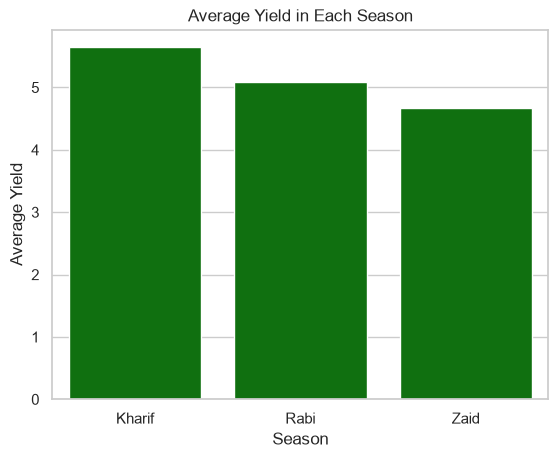

In [8]:
sns.barplot(x=season_data.index, y=season_data['Yield_Tonnes_Ha'], color='green')
plt.title('Average Yield in Each Season')
plt.xlabel('Season')
plt.ylabel('Average Yield')
plt.show()


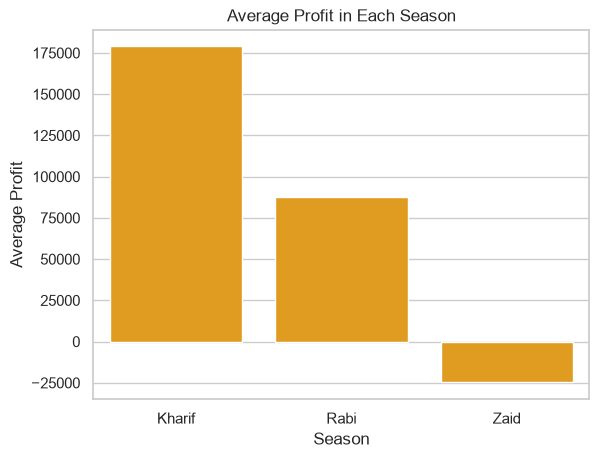

In [9]:
sns.barplot(x=season_data.index, y=season_data['Profit_INR'], color='orange')
plt.title('Average Profit in Each Season')
plt.xlabel('Season')
plt.ylabel('Average Profit')
plt.show()


## Average values by crop

Now I will compare the average yield and profit for different crops.


In [10]:
crop_data = data.groupby('Crop')[[
    'Yield_Tonnes_Ha',
    'Profit_INR'
]].mean()

crop_data


,Yield_Tonnes_Ha,Profit_INR
Crop,,
Chilli,1.540344,750878.342233
Cotton,1.225734,124546.915354
Groundnut,1.317924,44858.120283
Maize,2.717130,-83978.326679
Pulses,0.918198,-4238.052419
Rice,2.439413,-102213.504348
Sugarcane,46.938746,817187.986885
Wheat,2.109216,-123398.337134


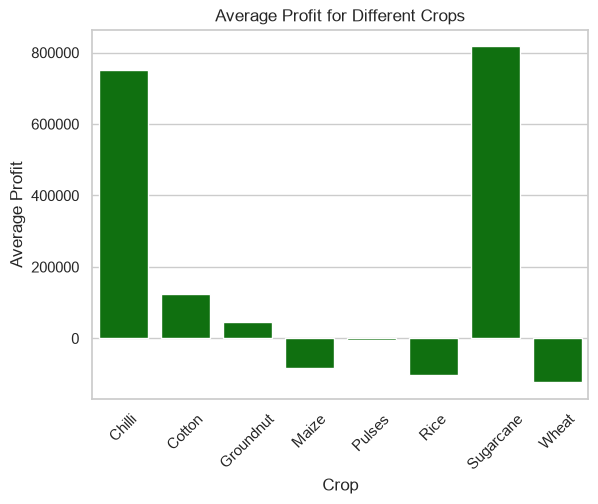

In [11]:
sns.barplot(x=crop_data.index, y=crop_data['Profit_INR'], color='green')
plt.title('Average Profit for Different Crops')
plt.xlabel('Crop')
plt.ylabel('Average Profit')
plt.xticks(rotation=45)
plt.show()


## Irrigation methods

I will compare the average yield for the different irrigation methods.


In [12]:
irrigation_data = data.groupby('Irrigation_Method')[[
    'Yield_Tonnes_Ha',
    'Profit_INR',
    'Water_Used_m3'
]].mean()

irrigation_data


,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3
Irrigation_Method,,,
Drip,6.620662,219625.997814,5918.747541
Flood,4.897724,73354.022901,8026.472519
Rainfed,4.613182,79050.365034,3549.554275
Sprinkler,5.188819,91121.079019,6208.258856


## Simple relationship between rainfall and yield

The following graph shows rainfall and yield for the farms in the dataset.


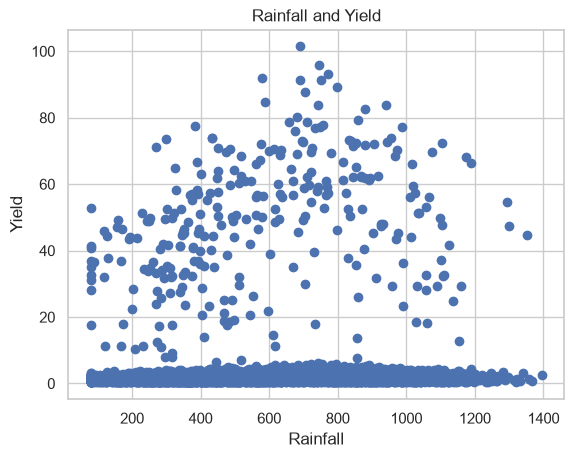

In [13]:
plt.scatter(data['Rainfall_mm'], data['Yield_Tonnes_Ha'])

plt.title('Rainfall and Yield')
plt.xlabel('Rainfall')
plt.ylabel('Yield')
plt.show()


## Comparing states

I will also compare the average profit in each state. This is a simple way to see if location makes a difference in the data.

In [14]:
state_data = data.groupby('State')['Profit_INR'].mean().sort_values(ascending=False).round(2)
state_data

State
Punjab            136025.64
Maharashtra       135428.86
Karnataka         119422.34
Tamil Nadu        117744.75
Gujarat           117568.24
Telangana         108829.62
Madhya Pradesh     86840.76
Andhra Pradesh     73453.53
Name: Profit_INR, dtype: float64

## Detailed analysis

The next sections are included to make the analysis more complete while still using simple commands.


## 1. Outlier investigation

An outlier is a value that is much higher or lower than most other values. I will use boxplots and the simple IQR method to investigate yield and profit.


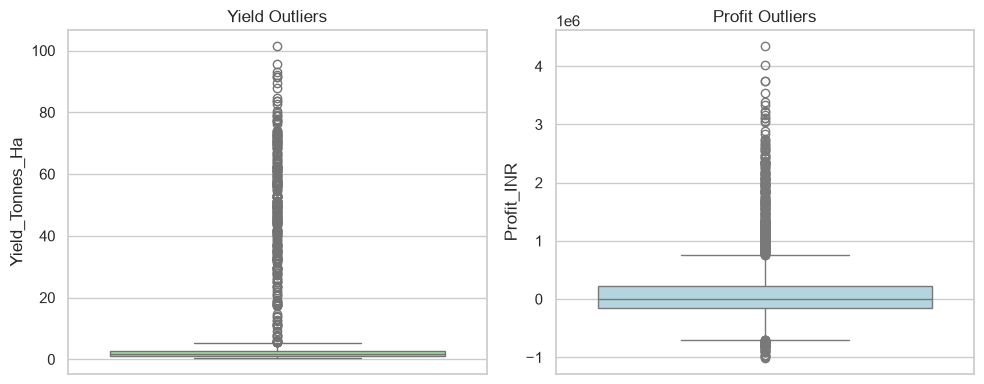

In [15]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=data['Yield_Tonnes_Ha'], color='lightgreen')
plt.title('Yield Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(y=data['Profit_INR'], color='lightblue')
plt.title('Profit Outliers')

plt.tight_layout()
plt.show()


In [16]:
# Finding possible outliers using the IQR method
for column in ['Yield_Tonnes_Ha', 'Profit_INR']:
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    low_value = q1 - 1.5 * iqr
    high_value = q3 + 1.5 * iqr
    number_of_outliers = ((data[column] < low_value) | (data[column] > high_value)).sum()
    print(column, 'possible outliers:', number_of_outliers)


Yield_Tonnes_Ha possible outliers: 302
Profit_INR possible outliers: 404


## 2. Univariate analysis

Univariate analysis looks at one variable at a time. Here I look at the distribution of yield and the number of records for each crop.


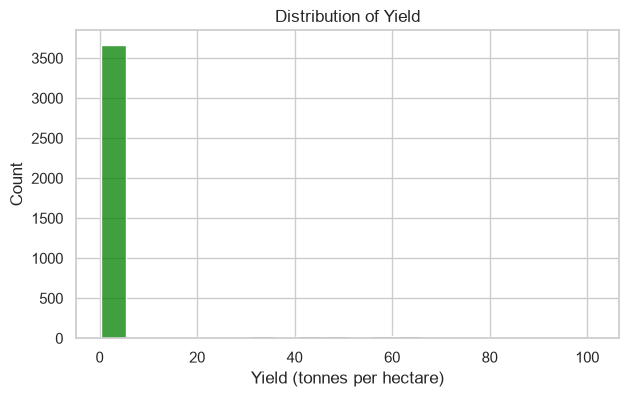

In [17]:
plt.figure(figsize=(7, 4))
sns.histplot(data['Yield_Tonnes_Ha'], bins=20, color='green')
plt.title('Distribution of Yield')
plt.xlabel('Yield (tonnes per hectare)')
plt.show()


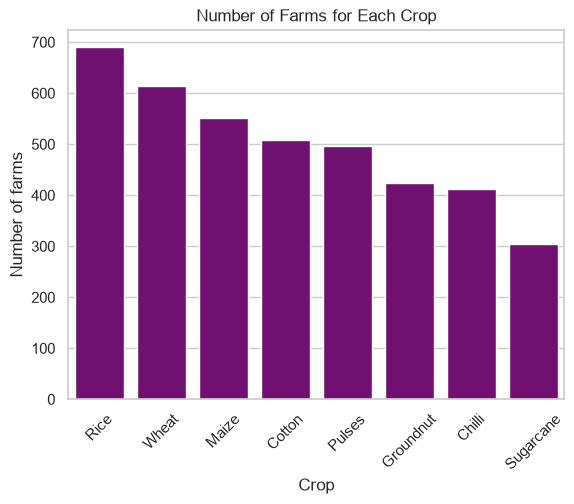

In [18]:
crop_count = data['Crop'].value_counts()
sns.barplot(x=crop_count.index, y=crop_count.values, color='purple')
plt.title('Number of Farms for Each Crop')
plt.xlabel('Crop')
plt.ylabel('Number of farms')
plt.xticks(rotation=45)
plt.show()


## 3. Bivariate analysis

Bivariate analysis studies two variables together. I will compare rainfall with yield and also compare profit across seasons.


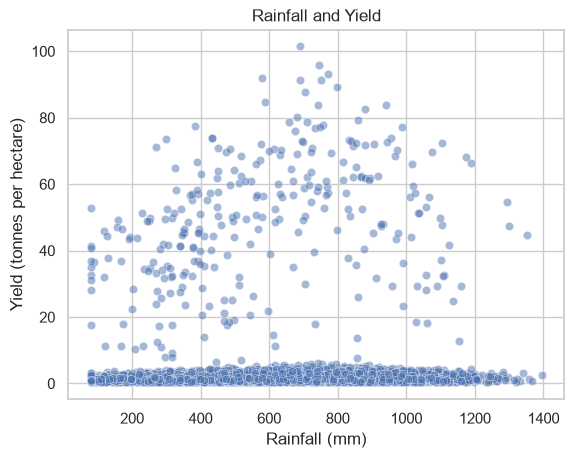

In [19]:
sns.scatterplot(data=data, x='Rainfall_mm', y='Yield_Tonnes_Ha', alpha=0.5)
plt.title('Rainfall and Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (tonnes per hectare)')
plt.show()


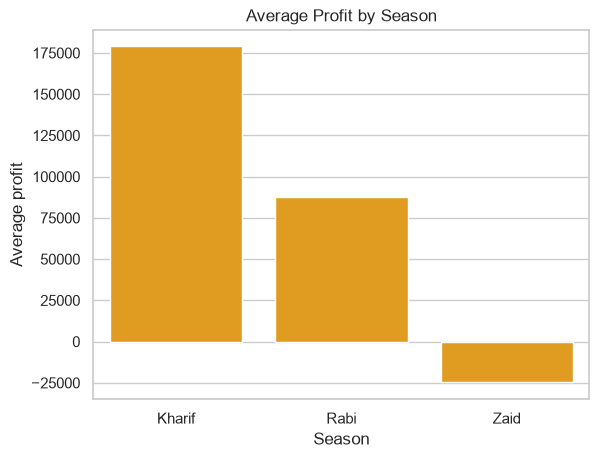

In [20]:
sns.barplot(data=data, x='Season', y='Profit_INR', errorbar=None, color='orange')
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average profit')
plt.show()


## 4. Multivariate analysis

Multivariate analysis looks at more than two variables together. This table compares crop yield across both crop and season.


In [21]:
crop_season = data.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
).round(2)

crop_season


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


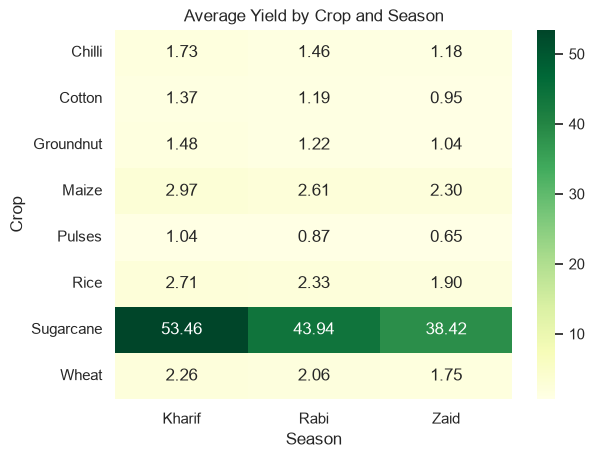

In [22]:
sns.heatmap(crop_season, annot=True, fmt='.2f', cmap='YlGn')
plt.title('Average Yield by Crop and Season')
plt.show()


## 5. Correlation analysis

Correlation helps show whether numerical variables move together. It does not prove that one variable causes another.


In [23]:
correlation_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Profit_INR'
]

correlation_table = data[correlation_columns].corr().round(2)
correlation_table


,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Fertilizer_kg_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Profit_INR
Rainfall_mm,1.00,0.20,0.52,0.02,-0.02,0.03,0.11
Avg_Temperature_C,0.20,1.00,0.08,0.02,-0.03,0.01,0.01
Soil_Moisture_pct,0.52,0.08,1.00,0.01,-0.02,0.01,0.09
Fertilizer_kg_ha,0.02,0.02,0.01,1.00,0.02,0.00,-0.07
Seed_Quality_Score,-0.02,-0.03,-0.02,0.02,1.00,-0.01,0.01
Yield_Tonnes_Ha,0.03,0.01,0.01,0.00,-0.01,1.00,0.49
Profit_INR,0.11,0.01,0.09,-0.07,0.01,0.49,1.00


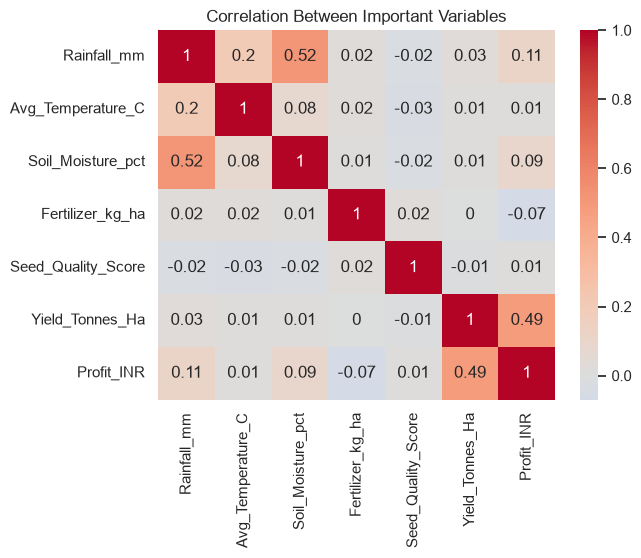

In [24]:
sns.heatmap(correlation_table, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Important Variables')
plt.show()


## 6. Three student-designed analyses

### Student analysis 1: profitable farms by season


In [25]:
data['Profitable'] = data['Profit_INR'] > 0
profitable_by_season = data.groupby('Season')['Profitable'].mean() * 100
profitable_by_season.round(2)


Season
Kharif    57.79
Rabi      48.86
Zaid      35.52
Name: Profitable, dtype: float64

### Student analysis 2: best crop and season combinations


In [26]:
crop_season_profit = data.pivot_table(
    values='Profit_INR',
    index='Crop',
    columns='Season',
    aggfunc='mean'
).round(2)

crop_season_profit


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.42,638572.50,448659.09
Cotton,216999.55,107343.59,-53925.34
Groundnut,108265.44,10416.54,-68872.50
Maize,-39332.67,-89133.40,-194049.17
Pulses,43338.90,-14309.14,-139227.81
Rice,-64903.40,-98427.87,-227239.34
Sugarcane,1000790.81,731612.86,583635.80
Wheat,-105871.87,-119954.57,-193208.95


### Student analysis 3: irrigation and water use


In [27]:
irrigation_water = data.groupby('Irrigation_Method')[[
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Yield_Tonnes_Ha'
]].mean().round(2)

irrigation_water


,Water_Used_m3,Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha
Irrigation_Method,,,
Drip,5918.75,6.27,6.62
Flood,8026.47,3.44,4.90
Rainfed,3549.55,7.56,4.61
Sprinkler,6208.26,4.67,5.19


## 7. Main insights

Based on the tables and graphs, the main insights are:

1. The dataset contains 4,000 original farm records and 28 columns.
2. Some rainfall, soil moisture and yield values are missing, so the main analysis uses 3,968 complete rows.
3. Kharif has the highest average yield in this dataset.
4. Kharif also has the highest average profit.
5. Zaid has the lowest average disease and pest risk.
6. Sugarcane has the highest average profit among the crops.
7. Profitability is different across seasons, with Kharif having more profitable farms than Zaid.
8. Crop, state and irrigation method all show differences in average farm performance.

These are observations from this dataset. They should not be treated as proof that one factor always causes another.


## 8. Recommendations

1. Compare expected yield and profit before selecting a crop.
2. Select crops according to the season and local conditions.
3. Use rainfall, soil moisture and irrigation information when planning.
4. Give extra attention to groups with higher disease or pest risk.
5. Compare water use as well as yield when choosing an irrigation method.
6. Collect data for more years before making large farming decisions.


## 9. Limitations

- The data is from the supplied farms and may not represent every farm.
- The data is not a long-term time series.
- Correlation does not prove cause and effect.
- Prices and costs can change in different places and years.
- Missing values were removed for the main analysis, so some records were not used.


## Conclusion

After comparing the seasons, I found that Kharif has the highest average yield and average profit in this dataset. Zaid has the lowest average disease and pest risk. Sugarcane has the highest average profit among the crops in the data.

I also compared crops, irrigation methods and states. These comparisons show that farm performance can be different depending on the crop, location and irrigation method.

The charts in this project use both Matplotlib and Seaborn. Farmers can use these results as a starting point when planning crops and irrigation. More data from different years would make the conclusion stronger.


## Recommendations

1. Compare the average profit before selecting a crop.
2. Select crops according to the season.
3. Use irrigation methods carefully because water use is different.
4. Check rainfall and soil conditions before farming.
5. Collect more data in the future.


## Project checklist

Before submission, I confirm that the notebook includes:

- ☑ Dataset loaded successfully
- ☑ Top 5 rows analyzed
- ☑ Dataset shape and structure examined
- ☑ Data types examined
- ☑ Missing values identified and handled
- ☑ Duplicate records identified and handled
- ☑ Descriptive/statistical analysis performed
- ☑ Outliers investigated
- ☑ Univariate analysis completed
- ☑ Bivariate analysis completed
- ☑ Multivariate analysis completed
- ☑ Correlation analysis completed
- ☑ Seasonal comparisons performed
- ☑ At least 3 student-designed analyses completed
- ☑ At least 8 meaningful insights documented
- ☑ Evidence-based recommendations provided
- ☑ Limitations discussed
- ☑ Final conclusion provided
